In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
train_data = pd.read_excel('Data_Train.xlsx')
test_data = pd.read_excel('Test_set.xlsx')
train_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


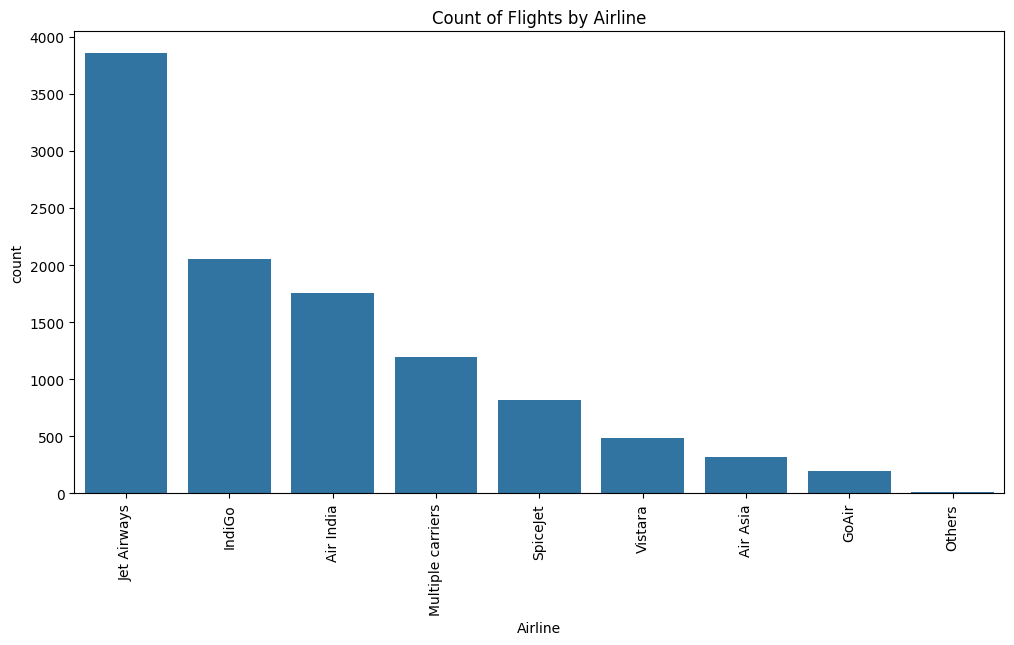

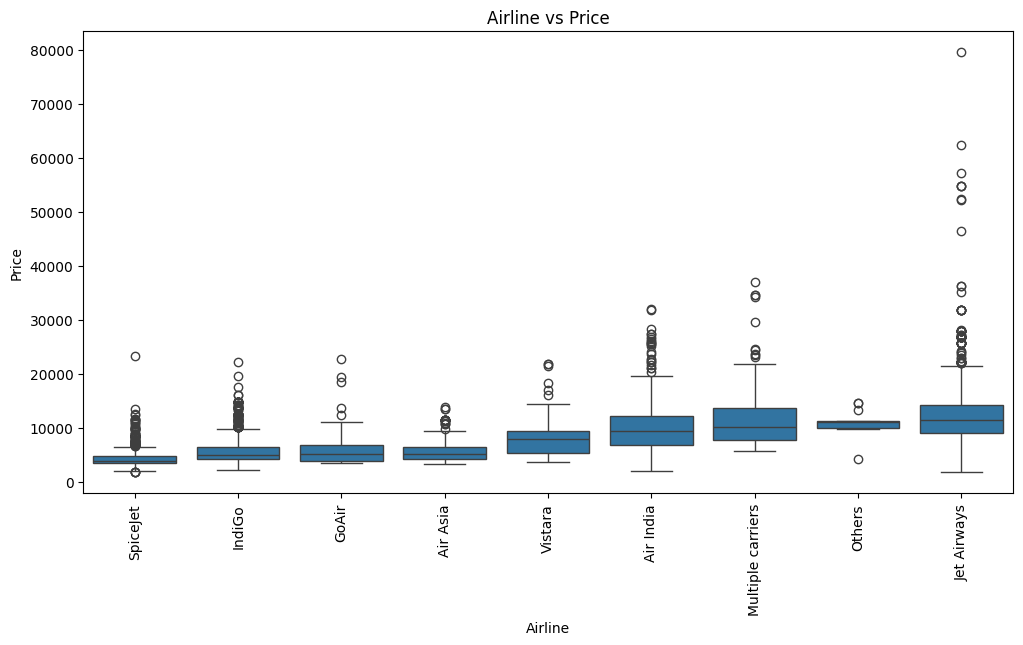

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Merging specified categories in the 'Airline' feature
train_data['Airline'] = train_data['Airline'].replace({
    'Vistara Premium economy': 'Vistara',
    'Jet Airways Business': 'Jet Airways',
    'Multiple carriers Premium economy': 'Others',
    'Trujet': 'Others'
})

test_data['Airline'] = test_data['Airline'].replace({
    'Vistara Premium economy': 'Vistara',
    'Jet Airways Business': 'Jet Airways',
    'Multiple carriers Premium economy': 'Others',
    'Trujet': 'Others'
})

# Re-plotting the updated Airline feature distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Airline', order=train_data['Airline'].value_counts().index)
plt.title('Count of Flights by Airline')
plt.xticks(rotation=90)
plt.show()

# Re-plotting the updated Airline feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=train_data,
    x='Airline',
    y='Price',
    order=train_data.groupby('Airline')['Price'].median().sort_values().index
)
plt.title('Airline vs Price')
plt.xticks(rotation=90)
plt.show()

12. Source and 13. Destination

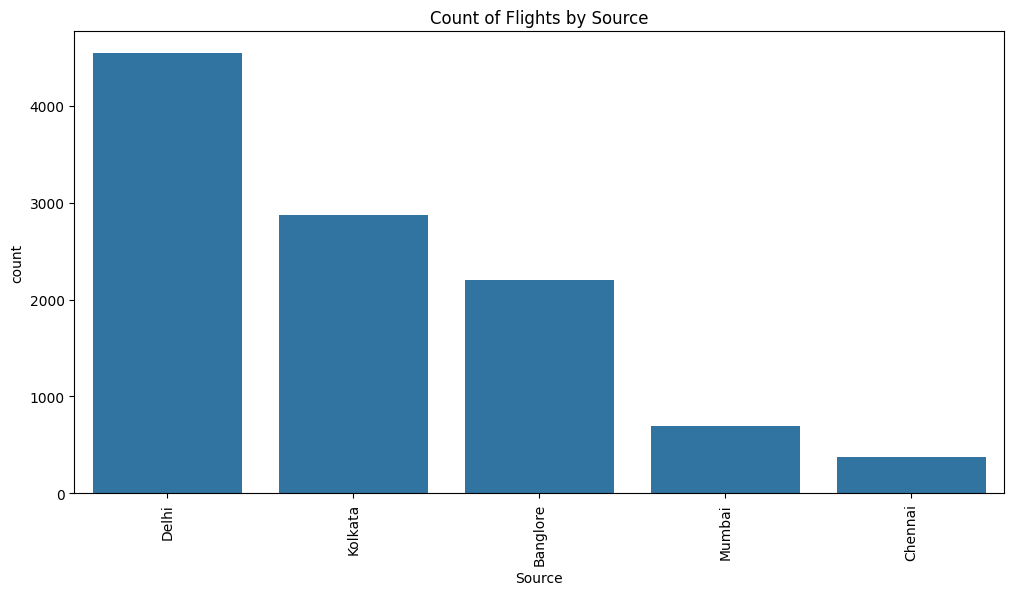

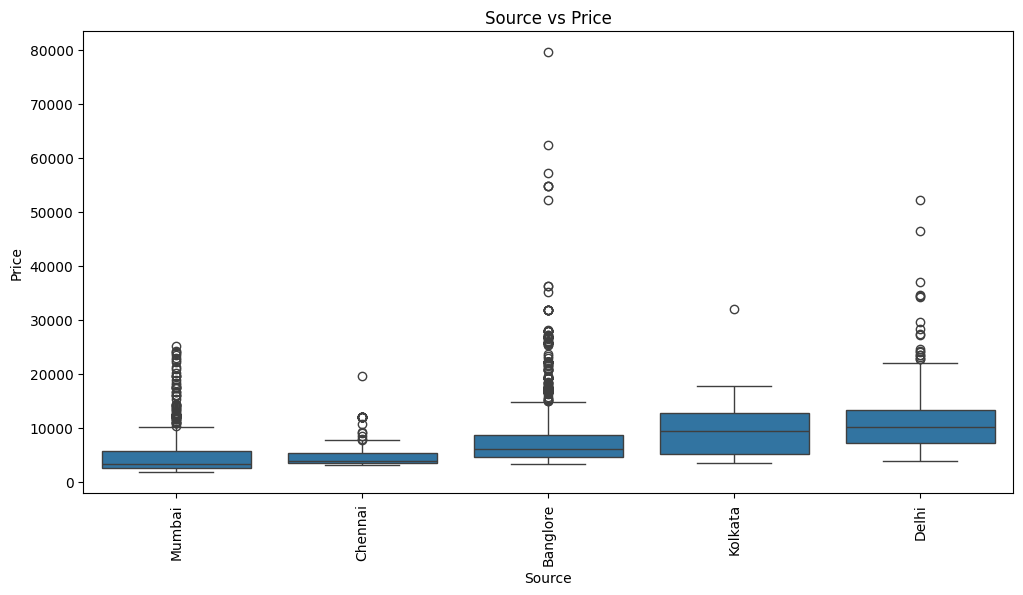

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Source distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Source', order=train_data['Source'].value_counts().index)
plt.title('Count of Flights by Source')
plt.xticks(rotation=90)
plt.show()

# Source feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data, x='Source', y='Price',
            order=train_data.groupby('Source')['Price'].median().sort_values().index)
plt.title('Source vs Price')
plt.xticks(rotation=90)
plt.show()

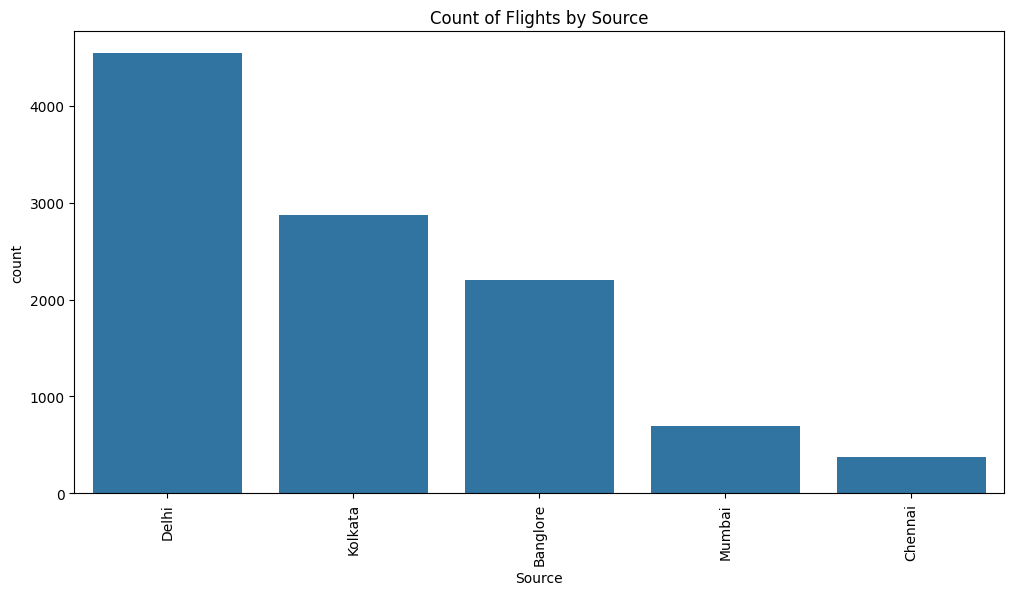

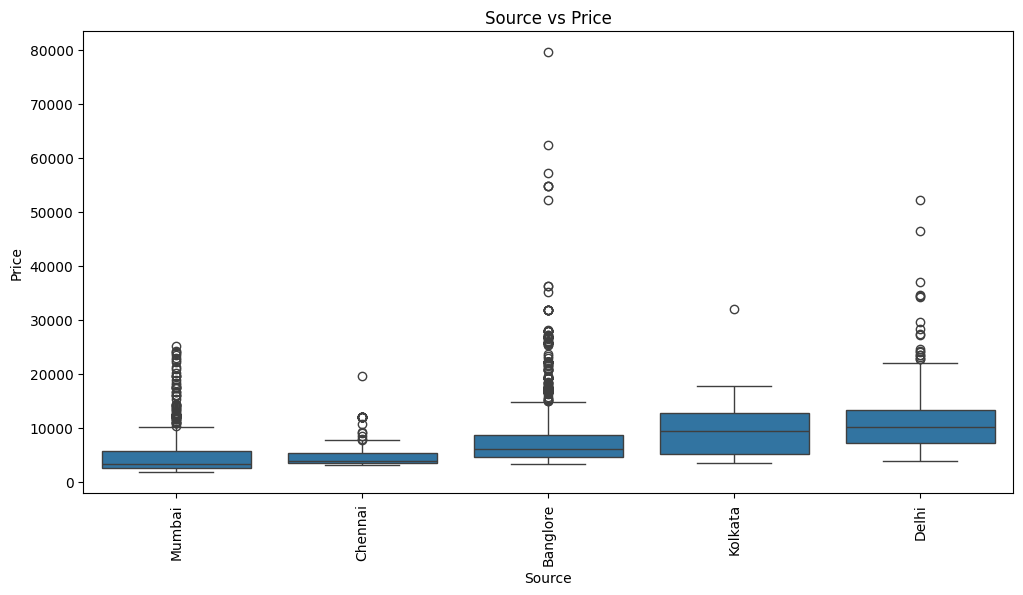

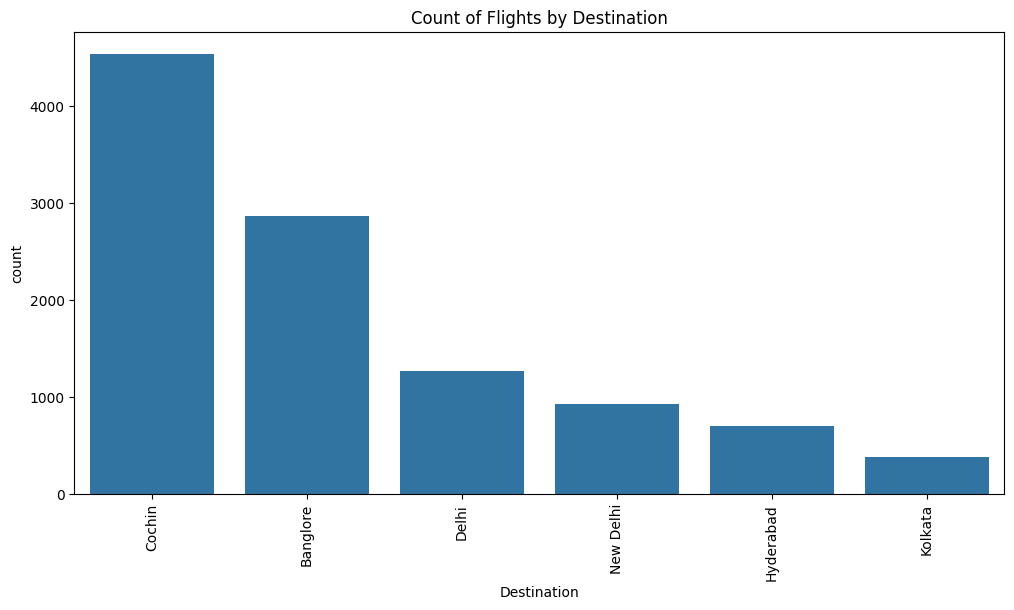

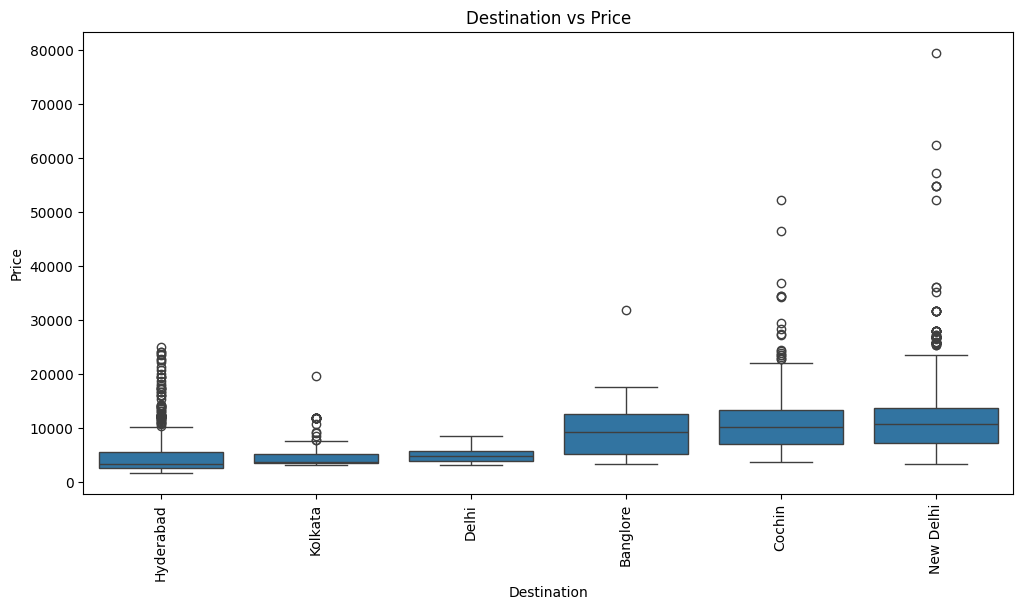

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- 12. Source ----
# Plotting Source distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Source', order=train_data['Source'].value_counts().index)
plt.title('Count of Flights by Source')
plt.xticks(rotation=90)
plt.show()

# Source feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=train_data,
    x='Source',
    y='Price',
    order=train_data.groupby('Source')['Price'].median().sort_values().index
)
plt.title('Source vs Price')
plt.xticks(rotation=90)
plt.show()

# ---- 13. Destination ----
# Plotting Destination distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Destination', order=train_data['Destination'].value_counts().index)
plt.title('Count of Flights by Destination')
plt.xticks(rotation=90)
plt.show()

# Destination feature dependence on Price
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=train_data,
    x='Destination',
    y='Price',
    order=train_data.groupby('Destination')['Price'].median().sort_values().index
)
plt.title('Destination vs Price')
plt.xticks(rotation=90)
plt.show()

14. Creating a new feautre as Route popularity

In [9]:
# Route Popularity - 1) combining the route using source - destination (source to destination)
train_data['Route'] = train_data['Source'] + '-' + train_data['Destination']
test_data['Route'] = test_data['Source'] + '-' + test_data['Destination']

In [10]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,Banglore-New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,Kolkata-Banglore,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,Delhi-Cochin,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,Kolkata-Banglore,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,Banglore-New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,Kolkata-Banglore,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,Kolkata-Banglore,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,Banglore-Delhi,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,Banglore-New Delhi,11:30,14:10,2h 40m,non-stop,No info,12648


In [11]:
#checking the counts for route popularity
route_popularity = train_data['Route'].value_counts()
route_popularity

,count
Route,
Delhi-Cochin,4537
Kolkata-Banglore,2871
Banglore-Delhi,1265
Banglore-New Delhi,932
Mumbai-Hyderabad,697
Chennai-Kolkata,381


In [12]:
## mapping these routes
train_data['Route_Popularity'] = train_data['Route'].map(route_popularity)
test_data['Route_Popularity'] = test_data['Route'].map(route_popularity)

In [13]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Route_Popularity
0,IndiGo,24/03/2019,Banglore,New Delhi,Banglore-New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,932
1,Air India,1/05/2019,Kolkata,Banglore,Kolkata-Banglore,05:50,13:15,7h 25m,2 stops,No info,7662,2871
2,Jet Airways,9/06/2019,Delhi,Cochin,Delhi-Cochin,09:25,04:25 10 Jun,19h,2 stops,No info,13882,4537
3,IndiGo,12/05/2019,Kolkata,Banglore,Kolkata-Banglore,18:05,23:30,5h 25m,1 stop,No info,6218,2871
4,IndiGo,01/03/2019,Banglore,New Delhi,Banglore-New Delhi,16:50,21:35,4h 45m,1 stop,No info,13302,932
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,Kolkata-Banglore,19:55,22:25,2h 30m,non-stop,No info,4107,2871
10679,Air India,27/04/2019,Kolkata,Banglore,Kolkata-Banglore,20:45,23:20,2h 35m,non-stop,No info,4145,2871
10680,Jet Airways,27/04/2019,Banglore,Delhi,Banglore-Delhi,08:20,11:20,3h,non-stop,No info,7229,1265
10681,Vistara,01/03/2019,Banglore,New Delhi,Banglore-New Delhi,11:30,14:10,2h 40m,non-stop,No info,12648,932
